In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("ecommerce_customer_data_large.csv")
df

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [4]:
df.shape

(250000, 13)

In [5]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

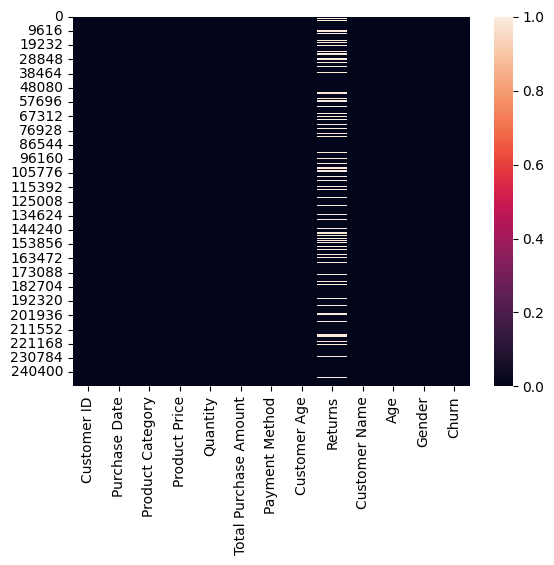

In [6]:
sns.heatmap(df.isnull())
plt.show()

In [7]:
df.drop("Returns",axis=1,inplace=True)

In [8]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

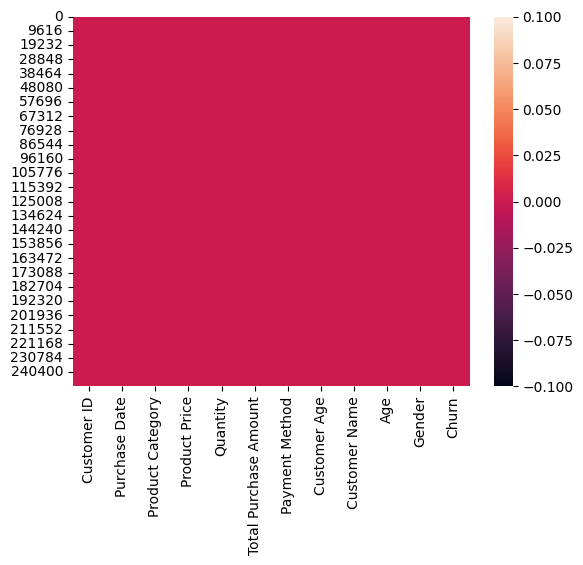

In [9]:
sns.heatmap(df.isnull())
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [12]:
#step 2 future engineering 
df.columns
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,John Rivera,31,Female,0


In [13]:
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])

In [14]:
df.dtypes

Customer ID                       int64
Purchase Date            datetime64[ns]
Product Category                 object
Product Price                     int64
Quantity                          int64
Total Purchase Amount             int64
Payment Method                   object
Customer Age                      int64
Customer Name                    object
Age                               int64
Gender                           object
Churn                             int64
dtype: object

In [15]:
#recency
import datetime as dt

In [16]:
import pandas as pd
import datetime as dt

# Date convert
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Define today
today = df['Purchase Date'].max()

# Recency
recency = df.groupby('Customer ID')['Purchase Date'].max().reset_index()
recency['Recency'] = (today - recency['Purchase Date']).dt.days
recency = recency[['Customer ID', 'Recency']]


In [17]:


# Frequency
frequency = df.groupby('Customer ID').size().reset_index(name='Frequency')



In [18]:


# Monetary
monetary = df.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']



In [19]:
# Combine
rfm = recency.merge(frequency, on='Customer ID')
rfm = rfm.merge(monetary, on='Customer ID')

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,288,3,6290
1,2,72,6,16481
2,3,222,4,9423
3,4,441,5,7826
4,5,424,5,9769


In [20]:
# STEP 7: RFM Scoring
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# STEP 8: Combine Score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# STEP 9: Output
print(rfm.head())

   Customer ID  Recency  Frequency  Monetary R_score F_score M_score RFM_Score
0            1      288          3      6290       2       1       1       211
1            2       72          6     16481       4       4       4       444
2            3      222          4      9423       3       2       2       322
3            4      441          5      7826       1       3       2       132
4            5      424          5      9769       2       3       2       232


In [21]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['M_score'] >= 4:
        return 'Big Spenders'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [22]:
rfm['Segment'].value_counts()

Segment
At Risk             18184
Recent Customers    17787
Loyal Customers      9218
Big Spenders         2287
Champions            2185
Name: count, dtype: int64

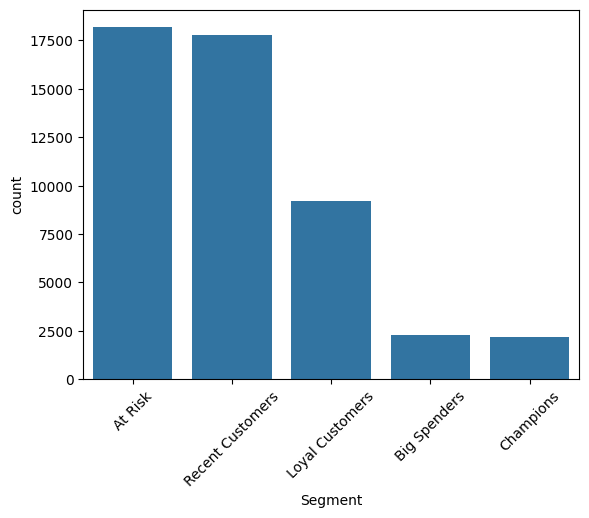

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.show()

In [24]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [25]:
#purches pattern analysis
df.groupby("Product Category")["Total Purchase Amount"].sum().sort_values(ascending=False)

Product Category
Home           171138916
Clothing       170716122
Electronics    170146025
Books          169345236
Name: Total Purchase Amount, dtype: int64

C:\Users\shrad\AppData\Local\Temp\ipykernel_2100\3840180247.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


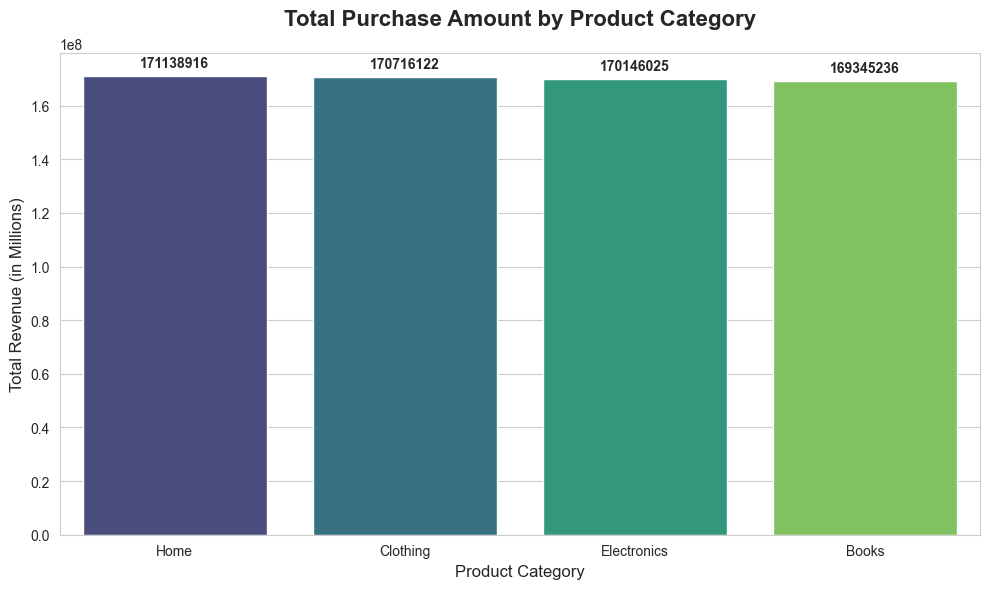

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

category_data = df.groupby("Product Category")["Total Purchase Amount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")


plot = sns.barplot(
    x="Product Category", 
    y="Total Purchase Amount", 
    data=category_data, 
    palette="viridis" 
)


plt.title("Total Purchase Amount by Product Category", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue (in Millions)", fontsize=12)

for p in plot.patches:
    plot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
payment_counts=df["Payment Method"].value_counts
print(payment_counts)


<bound method IndexOpsMixin.value_counts of 0              PayPal
1              PayPal
2         Credit Card
3                Cash
4              PayPal
             ...     
249995           Cash
249996    Credit Card
249997           Cash
249998           Cash
249999           Cash
Name: Payment Method, Length: 250000, dtype: object>


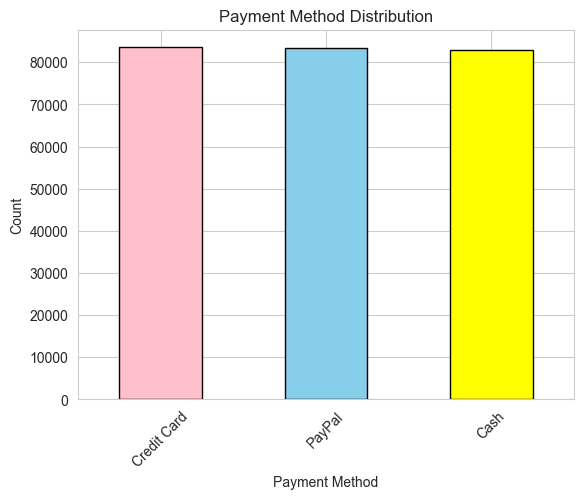

In [28]:
import matplotlib.pyplot as plt

payment_counts = df["Payment Method"].value_counts()


payment_counts.plot(kind="bar",color=["pink","skyblue","yellow"],edgecolor="black")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [29]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Month"] = df["Purchase Date"].dt.month

monthly_sales = df.groupby("Month")["Total Purchase Amount"].sum()
print(monthly_sales)

Month
1     62201958
2     57050354
3     62355745
4     60217450
5     62533980
6     60286066
7     62587751
8     63063912
9     51763012
10    46595245
11    45604668
12    47086158
Name: Total Purchase Amount, dtype: int64


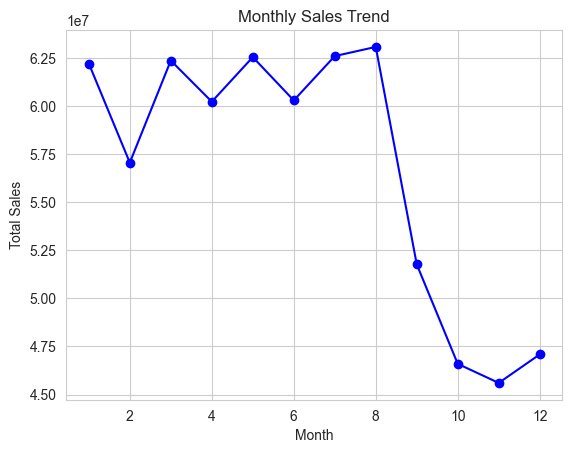

In [30]:
monthly_sales.plot(kind="line", marker="o", color="blue")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

In [31]:
df = df.merge(rfm[["Segment"]], left_on="Customer ID", right_index=True, how="left")

In [32]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Customer Name', 'Age', 'Gender', 'Churn', 'Month', 'Segment'],
      dtype='object')


In [33]:
segment_sales = df.groupby("Segment")["Total Purchase Amount"].sum().sort_values(ascending=False)
print(segment_sales)

Segment
At Risk             247948179
Recent Customers    242979587
Loyal Customers     125416967
Big Spenders         30784215
Champions            29579461
Name: Total Purchase Amount, dtype: int64


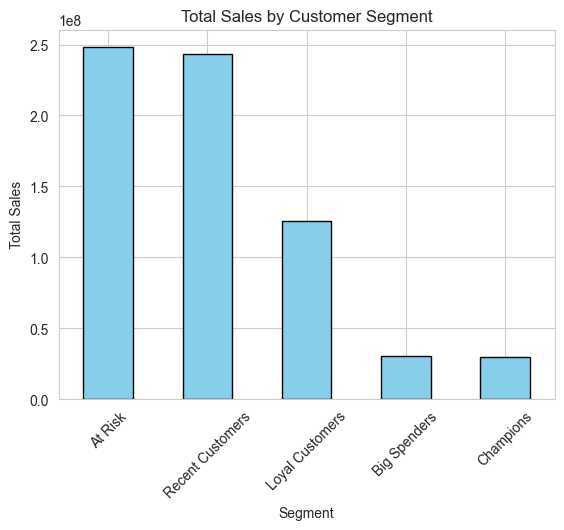

In [34]:
import matplotlib.pyplot as plt

segment_sales.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

In [35]:
quantity_counts = df["Quantity"].sum()
print(quantity_counts)

751234


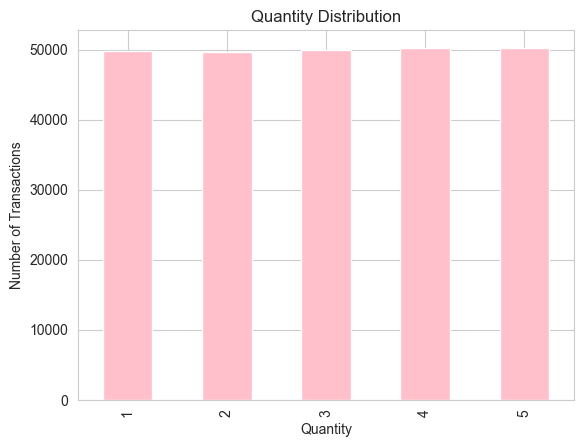

In [36]:

import matplotlib.pyplot as plt

# Quantity distribution
quantity_counts = df["Quantity"].value_counts().sort_index()

quantity_counts.plot(
    kind="bar",
    color="pink",
    
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

plt.show()


In [37]:
#churn analysis
churn_counts = df["Churn"].value_counts()
print(churn_counts)

Churn
0    199870
1     50130
Name: count, dtype: int64


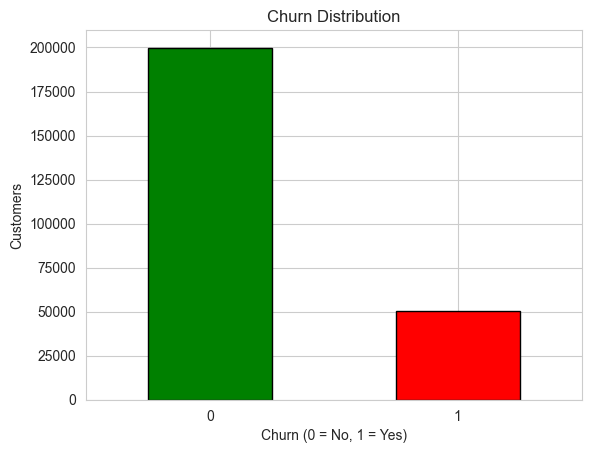

In [38]:
churn_counts.plot(kind="bar", color=["green","red"], edgecolor="black")

plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customers")

plt.xticks(rotation=0)
plt.show()

In [39]:
import pandas as pd

segment_churn = pd.crosstab(df["Segment"], df["Churn"])
print(segment_churn)

Churn                 0      1
Segment                       
At Risk           72656  18326
Big Spenders       9031   2385
Champions          8726   2153
Loyal Customers   36800   9258
Recent Customers  71189  17753


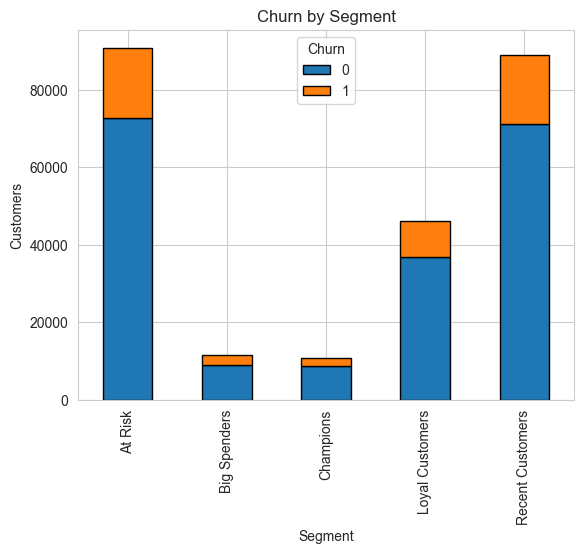

In [40]:
segment_churn.plot(kind="bar", stacked=True, edgecolor="black")

plt.title("Churn by Segment")
plt.xlabel("Segment")
plt.ylabel("Customers")

plt.show()

In [42]:
rfm = rfm.merge(df[["Customer ID", "Churn"]], left_index=True, right_on="Customer ID", how="left")

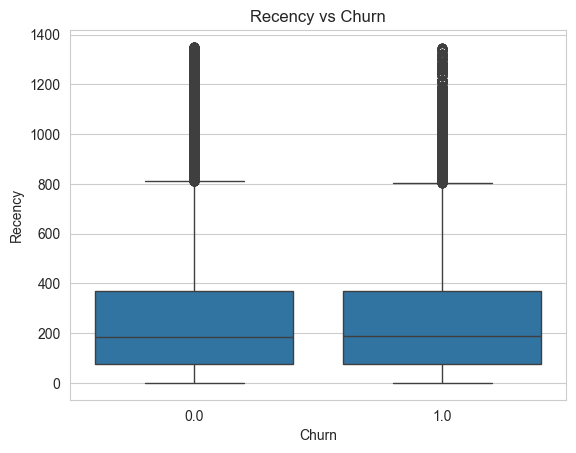

In [43]:
import seaborn as sns

sns.boxplot(x="Churn", y="Recency", data=rfm)

plt.title("Recency vs Churn")
plt.show()

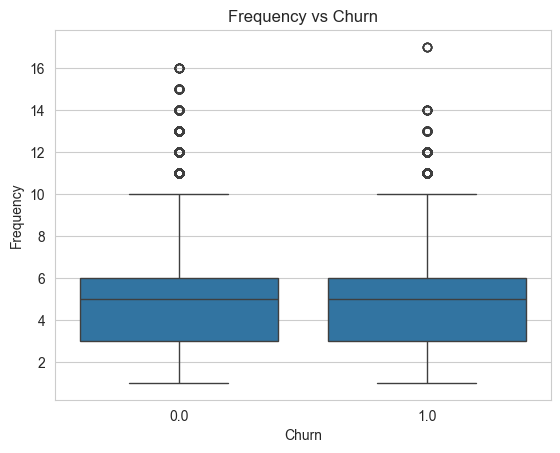

In [44]:
sns.boxplot(x="Churn", y="Frequency", data=rfm)

plt.title("Frequency vs Churn")
plt.show()

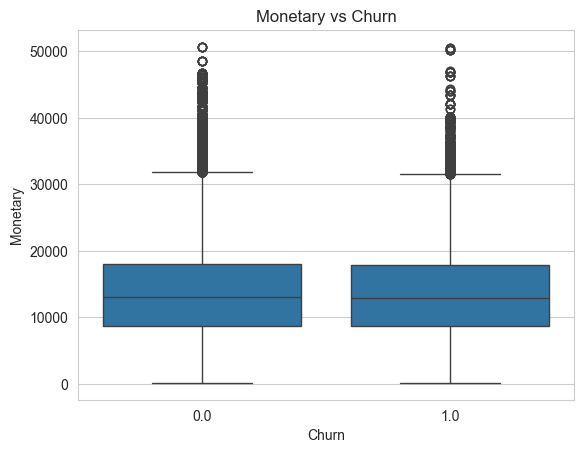

In [45]:
sns.boxplot(x="Churn", y="Monetary", data=rfm)

plt.title("Monetary vs Churn")
plt.show()

In [ ]:
# The Home category shows the highest purchase activity.
    
# Credit cards are the most preferred payment method among customers.
    
# Sales display an overall increasing trend followed by a slight decline.
    
# A large number of customers fall under the “At Risk” segment.
    
# Purchase quantity remains consistent across most transactions.
    
# Customers with lower monetary value are more likely to churn.
    
# The “At Risk” segment shows the highest probability of churn.
    
# Consistent patterns across RFM metrics indicate that low customer engagement leads to higher churn risk.
    

In [ ]:
Focus marketing efforts on the Home category, as it shows the highest purchase activity, to further boost sales and engagement.
    
Strengthen customer retention strategies for the “At Risk” segment by offering personalized discounts, reminders, and loyalty rewards to reduce churn.
    
Promote digital payment incentives, especially for credit card users, such as cashback or reward points to increase repeat purchases.
    
Target customers with low monetary value and low engagement using reactivation campaigns (email offers, coupons, or win-back messages).
Monitor RFM metrics regularly and create automated alerts for declining engagement to take early action before customers move into churn risk.